$$
\gdef\trace{\text{Tr}}
\gdef\ket#1{\vert#1\rangle}
\gdef\innerprod#1#2{\langle #1 \vert #2 \rangle}
\gdef\ksymm{\mathcal{K}}
$$

### *1. many-body bootstrap*
Solving the groundstate of a general Hamiltonian,
$$
    \min_\rho \trace\left[\rho H\right] \quad \text{s.t.}\quad \rho^\dag=\rho,\ \trace\rho = 1,\ \rho\succcurlyeq 0.
$$
The density matrix $\rho$ is a positive semi-definite (PSD), normalized hermitian matrix. PSD means that for any state $\vert\phi\rangle$,
$$
    \langle\phi\vert\rho\vert\phi\rangle = \sum_i p_i \vert \innerprod{\phi}{\psi_i} \vert^2 \geqslant 0.
$$
Variational methods parameterize $\rho$ with controlled number of parameters, usually scaling with system size in a power law, by adopting wisely a variational ansatz $\rho_\theta$. The original problem is transformed into solving $\rho_\theta$, which yields strictly an upper bound of groundstate energy.

Instead, bootstrap methods enlarge the target space of $\rho$ by relaxing the semi-definite constraints. Rewrite the PSD condition as
$$
    \rho\succcurlyeq 0 \ \iff\ \rho = O^\dag O \ \iff\ \forall S\succcurlyeq 0,\ \trace\left[\rho S\right] \geqslant 0.
$$
One relaxes $S$ to a set of chosen PSD matrix $S_i$ such that the original problem is reduced to an easier one,
$$
    \min_\rho \trace\left[\rho H\right] \quad \text{s.t.}\quad \rho^\dag=\rho;\ \trace\rho = 1;\ \forall\ S_i\succcurlyeq 0,\ \trace\left[\rho S_i\right] \geqslant 0.
$$
This gives strictly a lower bound of groundstate energy. The effectiveness of the method therefore relies on the wise choice of $S_i$ set.

Consider an operator basis $\{O_i\}$, where the Hamiltonian can be represented as a linear combination of $O_i^\dag O_j$. For any operator $O=w_i O_i$, $O^\dag O$ is a PSD operator and we require
$$
    w_i^\ast w_j \trace \left[\rho O_i^\dag O_j\right] \geqslant 0.
$$
If we define $M_{ij}\overset{!}{=}\trace\left[\rho O_i^\dag O_j\right]=\langle O_i^\dag O_j\rangle$, the above positivity constraints state that $M$ is a PSD matrix. Specifically, we focus on the stationary states of $H$ where $\rho$ commutes with $H$; this imposes stationarity constraints on the moment expectations in $M$ through
$$
    \left\langle \left[H,O\right]\right\rangle = 0,
$$
for arbitrary $O$. A good starting point is to generate constraints from moment operators $O=O_i^\dag O_j$. Moreover, a clever application of symmetries would impose additional constraints. Other basic constraints include:
* $\trace\rho=1$ requires $M_{11} = 1$;

* $\rho^\dag = \rho$ yields $\langle O_i^\dag O_j\rangle^\ast = \langle O_j^\dag O_i\rangle$ such that $M$ is a hermitian.

In practice, one reduces the number of independent moment expectations in $M_{ij}$ using *constraints and symmetries* and can in principle sample them to check whether $M$ is a PSD matrix. This generates a set of feasible regions for the operator spectrum, including the energy. By considering increasingly large operator bases $\{O_i\}$, the result of the optimization problem approaches the exact value, yielding a hierarchy of estimations.

*Complexity:*

$\text{\color{red}todo}$

Refer to:
* https://arxiv.org/pdf/2406.17844, extensive benchmark on TFIM

* https://arxiv.org/pdf/2111.13007

* https://github.com/EverettYou/QuantumBootstrap, bootstrap in the krylov space [?]

### *2. Transverse Ising chain*
$$
    H = \sum_i -J Z_i Z_{i+1} - h X_i.
$$
The $2^N$-dim many-body basis are constructed via the tensor product $\ket{\sigma}=\bigotimes_{i=1}^{N}\vert\sigma_i\rangle$, where each local state $\vert\sigma_i\rangle$ is an eigenstate of $Z_i$ with eigenvalue $\sigma_i$. A general state $\ket{\psi}$ is a linear combination of $\ket{\sigma}$, $\ket{\psi}=\sum_\sigma a_\sigma\ket{\sigma}$, usually denoted as a $2^N$-dim column vector $(\dots, a_\sigma, \dots)^T$.

#### *2.0. Symmetry revisited*
General symmetries can be devided into basically two classes, unitary symmetries
$$
    \ket{\psi} \to U \ket{\psi},
$$
and anti-unitary symmetries
$$
    \ket{\psi} \to U \ksymm\ket{\psi} = U\ket{\psi}^\ast,
$$
where $\ksymm$ denotes the operation of complex conjugation and $\ksymm^2=1$. $\ksymm$ is anti-unitary because first it is anti-linear
$$
    \ksymm\ket{\psi} \overset{!}{=} \ket{\psi}^\ast = \sum_\sigma a_\sigma^\ast \ket{\sigma}.
$$
It satisfies
$$
    \langle\ksymm\phi\vert\ksymm\psi\rangle = \innerprod{\phi}{\psi}^\ast,
$$
which is consistent with *Wigner theorem* stating that two states transformed under the symmetry should have a preserved inner product amplitude. The Wigner theorem also forbids any mixed operation, $\ket{\psi} \to U_1 \ket{\psi} + U_2\ksymm \ket{\psi}$,to be a symmetry. Equivalently, in the Heisenberg picture, an operator $O$ transforms as $O \to U^\dag O U$ under unitary symmetries and as $O \to \ksymm U^\dag O U \ksymm$ under anti-unitary symmetries, with the operators applied sequentially from right to left. The anti-unitary operation $\ksymm O \ksymm$ is understood by acting it on an arbitrary state, which yields
$$
    \ket{\ksymm O \ksymm \psi}_{\sigma'}
    = \sum_\sigma \left(O_{\sigma'\sigma} a_\sigma^\ast \ket{\sigma}\right)^\ast
    = \sum_\sigma O^\ast_{\sigma'\sigma} a_\sigma \ket{\sigma}
    = \ket{O^\ast \psi}_{\sigma'},
$$
and $\ksymm O \ksymm = O^\ast$.

#### *2.1. $\ksymm$-symmetry*
For the transverse Ising chain, we consider the simplest anti-unitary symmetry $\ksymm$. The Hamiltonian in our chosen basis $\{\ket{\sigma}\}$ is expressed as a purely real matrix $H^\ast=H$, and is hence invariant under complex conjugation $\ksymm$,
$$
    \ksymm H \ksymm = H.
$$
Assuming $\ket{\psi}$ is an eigenstate of $H$, we have
$$
    H \ket{\psi} = \ksymm H \ksymm \ket{\psi} = E \ket{\psi} \implies H \ket{\psi}^\ast = E \ket{\psi}^\ast.
$$
Therefore, $\ket{\psi}$ and $\ket{\psi}^\ast$ have the same energy. The logic is that if $\ket{\psi}$ and $\ket{\psi}^\ast$ are linearly independent, we can construct
$$
    \ket{\psi_+} = \frac{1}{\sqrt{2}} \left(\ket{\psi} + \ket{\psi}^\ast\right), \quad
    \ket{\psi_-} = \frac{i}{\sqrt{2}} \left(\ket{\psi} - \ket{\psi}^\ast\right),
$$
and both $\ket{\psi_\pm}$ are purely real-valued, $\ksymm$-even states. Otherwise, if $\ket{\psi}$ and $\ket{\psi}^\ast$ are the same state, then $\ket{\psi}$ itself is real-valued.  This guarantees that all energy eigenstates can be safely chosen as purely real-valued and $\ksymm$-even states without loss of generality. Note this is equivalent to stating that  the density matrix $\rho = \sum_n p_n \ket{\psi_n}\langle\psi_n\vert$ can be chosen as real-valued, symmetric and $\ksymm$-even matrices, where $\ket{\psi_n}$ can be any normalized $\ksymm$-even pure state. Below we will stick to the Heisenberg picture and assume a $\ksymm$-even density matrix $\rho_+$ throughout. This extends our discussions to mixed states such as thermal density matrix $\rho\sim e^{-\beta H}$ with very little effort.

To proceed, we categorize the operators based on their parity under $\ksymm$ into $\ksymm$-even and $\ksymm$-odd classes.
$$
    O = \underbrace{\frac{1}{2}\left(O + O^\ast\right)}_{O_+} + \underbrace{\frac{1}{2}\left(O - O^\ast\right)}_{O_-},
$$
and $\ksymm O_\pm\ksymm = O_\pm^\ast = \pm O_\pm$. The Hamiltonian $H$ is obviously $\ksymm$-even. Also, the $\ksymm$-parity is multiplicative, following a $\mathbb{Z}_2$ grading algebra: $O_\pm O_\pm=O_+$ and $O_\pm O_\mp=O_-$. For the transverse Ising chain, we consider a set of operator $\{O_i\}$ and each $O_i$ is a Pauli string $O=\bigotimes_{i=1}^N \sigma^\alpha_i$. $\ksymm$ symmetry applies on such a Pauli string as
$$
    \ksymm \left(\bigotimes_{i=1}^N \sigma^\alpha_i\right) \ksymm = \bigotimes_{i=1}^N \ksymm \sigma^\alpha_i \ksymm.
$$
Hence to determine whether a Pauli string is $K$-even or $K$-odd is simply to count the number of $Y$ operators it contains, $\ksymm O\ksymm = (-1)^{N_y} O$. Note that given a $\ksymm$-even $\rho_+$,
$$
    \langle O_\pm\rangle
    = \trace \left[\rho_+ O_\pm\right]
    = \pm \trace \left[\rho_+ \ksymm O_\pm \ksymm\right]
    = \pm \trace \left[\rho_+ O_\pm^\ast \right]
    = \pm \langle O_\pm\rangle^\ast.
$$
Therefore, $\langle O_+\rangle$ is real and $\langle O_-\rangle$ is purely imaginary with $O_\pm$ here not necessarily a hermitian.

We will show that the presence of $\ksymm$-symmetry facilitates the bootstrap calculation in the following aspects:

* It reveals the intrinsic structure of the moment matrix $M_{ij}=\langle O^\dag_i O_j\rangle$ such that we can transform it into a real-valued matrix. Assuming that we divide the Pauli string basis $\{O_i\}$ by class $\{O_+,O_-\}$, the moment matrix is expressed into a block form based on our discussion above
  $$
        M = \begin{pmatrix}M_1 & iM_3\\[5pt]-iM_3^T & M_2\\\end{pmatrix},
  $$
  where $M_1$ and $M_2$ are real symmetric matrices and $M_3$ a real matrix. This intrinsic structure of $M$ facilitates SDP calculations if we further consider a unitary transformation
  $$
        U = \begin{pmatrix}I & 0\\ 0 & iI\\\end{pmatrix}, \quad
        \tilde{M} = U^\dag M U = \begin{pmatrix}M_1 & -M_3\\[5pt]-M_3^T & M_2\\\end{pmatrix}.
  $$
  Now $\tilde{M}$ is a real symmetric matrix and by construction $M\succcurlyeq 0$ is equivalent to $\tilde{M}\succcurlyeq 0$. Since the backend SDP solvers are fundamentally designed to operate natively on real numbers, the bootstrap calculation shall benefit significantly from condensing $M$ from a hermitian to a symmetric matrix.

* It reduces the number of moment variables. In bootstrap, we identify the expectation values of Pauli strings $\mathcal{O}_{ij}$, associated to moment operators $O^\dag_i O_j$, as moment variables. A Pauli string is hermitian by nature, while it may differ from $O^\dag_i O_j$ by a pure real or imaginary factor and may have opposite parity. Consider a $\ksymm$-odd Pauli string, its expectation is purely complex given a symmetric $\rho_+$. And because Pauli string is a hermitian, its expecatation mush be real. This yields that the expectation of $K$-odd $\mathcal{O}_{ij}$ mush vanish and we only need to consider $K$-even ones as moment variables.

* It implies that nontrivial stationarity constraints, $\langle[H,O]\rangle=0$ can only be generated from $K$-odd Pauli strings $\mathcal{O}_{ij}$. By definition, $[H, \mathcal{O}_{ij}]$ shares identical parity with $\mathcal{O}_{ij}$ and is anti-hermitian as long as $\mathcal{O}_{ij}$ is hermitian. Furthermore, if $\mathcal{O}_{ij}$ is $\ksymm$-even, we deduce $\langle[H, \mathcal{O}_{ij}]\rangle \in \mathbb{R}$ from the fact that $[H, \mathcal{O}_{ij}]$ is $\ksymm$-even. However, the anti-hermiticity of $[H, \mathcal{O}_{ij}]$ ensures its expectation value to be purely imaginary. And we conclude $\langle[H, \mathcal{O}_{ij}]\rangle \equiv 0$ from deduction. As a result, only $\ksymm$-odd $\mathcal{O}_{ij}$ generates valid stationarity constraints.

For transverse Ising chain and general real-matrix Hamiltonians under certain basis, the assumption of real symmetric $\rho$ is physically natural and exact as long as we consider stationary states, including thermal equilibrium state. How to bootstrap dynamics? (find refs.)

#### *2.2. Benchmark with ED*

ED        time=0.299s    E_0/L=-1.27528715
basis0    time=1.015s    E_0/L=-1.30958350   status=optimal 
basis1    time=26.239s   E_0/L=-1.28185535   status=optimal 
basis2    time=119.791s  E_0/L=-1.27824390   status=optimal 


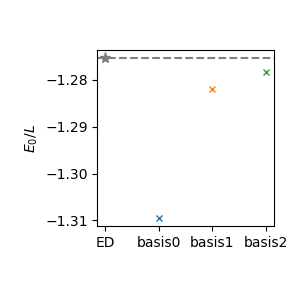

In [1]:
%reset -f
from ising._ed import gs as ed_gs
from ising.ising import IsingParams, IsingCompiler
from sdp import SDPSolver

import time
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib widget

def bootstrap_gs(L, J, h, basis, eps=1e-4, max_iters=5000):
    compiler = IsingCompiler(IsingParams(L=L, J=J, h=h))
    compiler.compile(basis)
    solver = SDPSolver()
    solver.build(compiler.sdp_data())
    value = solver.solve(solver='SCS', eps=eps, max_iters=max_iters)
    return value, compiler.summary(), solver.summary()


L = 16
J = 1.
h = 1.

basis0 = ['I', 'X', 'Y', 'Z', 'ZZ']
basis1 = basis0 + ['XX', 'YY', 'XZ', 'XY', 'YX', 'YZ', 'ZX', 'ZY', 'IX', 'IY', 'IZ']
basis2 = basis1 + ['XXX', 'XXY', 'XXZ', 'XYX', 'XYY', 'XYZ', 'XZX', 'XZY', 'XZZ']
bases = {
    'basis0': basis0,
    'basis1': basis1,
    'basis2': basis2,
}
eps = 1e-4
max_iters = 10_000

fig, ax = plt.subplots(1, 1, figsize=(3,3))

t0 = time.perf_counter()
e0 = ed_gs(L, J=J, h=h)
dt = time.perf_counter() - t0
print(
    f'{"ED":<10s}'
    f'{f"time={dt:.3f}s":<15s}'
    f'{f'E_0/L={e0/L:.8f}':<15s}'
)
ax.plot(['ED'], [e0/L], marker='*', markersize=8, color='tab:grey')
ax.axhline(y=e0/L, color='tab:grey', linestyle='dashed')

for name, basis in bases.items():
    t0 = time.perf_counter()
    e0_lower, compiler_summary, solver_summary = bootstrap_gs(
        L, J, h, basis, eps=eps, max_iters=max_iters,
    )
    dt = time.perf_counter() - t0
    print(
        f'{name:<10s}'
        f'{f"time={dt:.3f}s":<15s}'
        f'{f"E_0/L={e0_lower/L:.8f}":<20s}'
        f'{f"status={solver_summary["status"]}":<15s}'
    )
    ax.plot([name], [e0_lower/L], marker='x', markersize=5, markerfacecolor='none')

ax.set_ylabel(r'$E_0/L$')

ax.set_box_aspect(1)
fig.tight_layout()